Imports & Configuration

In [10]:
import pandas as pd
from collections import Counter
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

CHARGEMENT DES DONNÉES PRÉTRAITÉES

In [6]:
BASE_DIR = Path().resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# ── Chargement des variables (Features) ─────────────────────
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')

# ── Chargement de la cible (Target) ─────────────────────────
# .squeeze() : elle transforme le DataFrame (1 colonne) en une Series (vecteur 1D), ce qui évite les alertes (warnings) de Scikit-Learn/XGBoost.
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print("Données chargées avec succès !\n")
print(f" X_train (Entraînement) : {X_train.shape[0]:,} lignes, {X_train.shape[1]} colonnes")
print(f" X_test  (Test)         : {X_test.shape[0]:,} lignes, {X_test.shape[1]} colonnes")
print(f" y_train (Cible Train)  : {y_train.shape[0]:,} éléments")
print(f" y_test  (Cible Test)   : {y_test.shape[0]:,} éléments")

Données chargées avec succès !

 X_train (Entraînement) : 15,758 lignes, 14 colonnes
 X_test  (Test)         : 2,000 lignes, 14 colonnes
 y_train (Cible Train)  : 15,758 éléments
 y_test  (Cible Test)   : 2,000 éléments


PARAMÉTRAGE ET ENTRAÎNEMENT DE XGBOOST

In [7]:
# ── 1. Calcul du poids pour compenser le déséquilibre ───────
scale_pos = Counter(y_train)[0] / Counter(y_train)[1]
print(f" Poids des classes (Scale Pos Weight) = {scale_pos:.2f}")

# ── 2. Création du modèle XGBoost ───────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos, # Gestion interne du déséquilibre
    eval_metric='aucpr',        # Utilisation de la courbe PR (idéal pour la fraude)
    random_state=42,
    n_jobs=-1
)

print("Entraînement du modèle XGBoost en cours...")
xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("Entraînement terminé !")

 Poids des classes (Scale Pos Weight) = 1.00
Entraînement du modèle XGBoost en cours...
Entraînement terminé !


ÉVALUATION DES PERFORMANCES

 Score ROC-AUC : 0.9998
 Score PR-AUC  : 0.9882

 Rapport de classification :
              precision    recall  f1-score   support

Légitime (0)       1.00      1.00      1.00      1970
  Fraude (1)       0.91      0.97      0.94        30

    accuracy                           1.00      2000
   macro avg       0.95      0.98      0.97      2000
weighted avg       1.00      1.00      1.00      2000



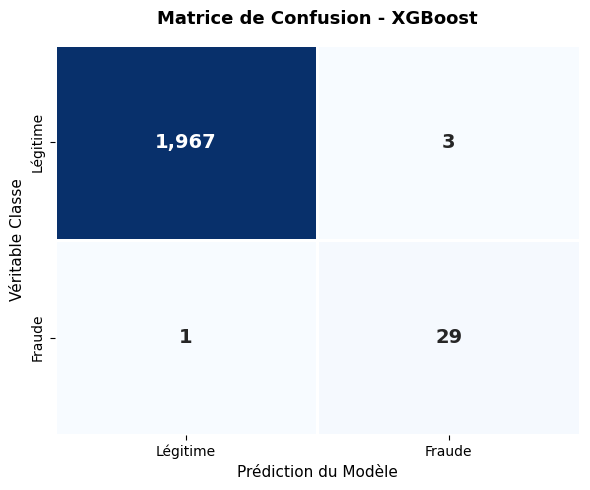

In [11]:
# ── 3. Prédictions ──────────────────────────────────────────
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

# ── 4. Métriques ────────────────────────────────────────────
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
prauc_xgb = average_precision_score(y_test, y_prob_xgb)

print(f" Score ROC-AUC : {auc_xgb:.4f}")
print(f" Score PR-AUC  : {prauc_xgb:.4f}")

print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_xgb, target_names=["Légitime (0)", "Fraude (1)"]))

# ── 5. Matrice de Confusion ───────────────────
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=["Légitime", "Fraude"], 
            yticklabels=["Légitime", "Fraude"],
            linewidths=1, linecolor='white',
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax)

ax.set_xlabel("Prédiction du Modèle", fontsize=11)
ax.set_ylabel("Véritable Classe", fontsize=11)
ax.set_title("Matrice de Confusion - XGBoost", fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

# Sauvegarde Graphique
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_plot_path = PLOT_DIR / 'xgboost_confusion_matrix.png'
plt.savefig(save_plot_path, bbox_inches='tight', dpi=300)

plt.show()

EXPORTATION DU MODÈLE POUR LA MISE EN PRODUCTION

In [13]:
# ── 6. Sauvegarde du modèle .pkl ────────────────────────────
MODEL_DIR = BASE_DIR / 'ml-models' / 'trained'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / 'xgb_fraud_model.pkl'
joblib.dump(xgb, model_path)

print(f" Modèle XGBoost sauvegardé avec succès dans : {model_path}")

 Modèle XGBoost sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\ml-models\trained\xgb_fraud_model.pkl
